### Regularization Assignments

Use the model below as a basis for comparison to your regularized models.

In [2]:
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import numpy as np
from sklearn.metrics import r2_score as r2
from sklearn.metrics import mean_absolute_error as mae


computers = pd.read_csv(r"C:\BIT_Data_analyst\05_regressions\01_lesson\Computers.csv")

computers.tail()

,price,speed,hd,ram,screen,cd,multi,premium,ads,trend
6254,1690,100,528,8,15,no,no,yes,39,35
6255,2223,66,850,16,15,yes,yes,yes,39,35
6256,2654,100,1200,24,15,yes,no,yes,39,35
6257,2195,100,850,16,15,yes,no,yes,39,35
6258,2490,100,850,16,17,yes,no,yes,39,35


In [3]:
# Use the dataframe below for model fitting, afterwards, feel free to try more feature engineering!

computers_eng = (
    pd.get_dummies(
        computers.assign(
            hd2 = computers["hd"] ** 2,
            hd3 = computers["hd"] ** 3,
        ),
    drop_first=True    
    )
)

In [18]:
from sklearn.model_selection import train_test_split

X = sm.add_constant(computers_eng.drop("price", axis=1))
y = np.log(computers["price"])

# Test Split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=12345)

# Train Split

X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=12345
)

In [19]:
X = X.astype(float) 
y = y.astype(float)
model = sm.OLS(y, X).fit()

#model.summary()

print(f"Training R2: {r2(y, model.predict(X))}")
print(f"Training MAE: {mae(y, model.predict(X))}")

Training R2: 0.806335850032755
Training MAE: 0.08738123579432258


In [21]:
print(f"Test R2: {r2(y_test, model.predict(X_test))}")
print(f"Test MAE: {mae(y_test, model.predict(X_test))}")

Test R2: 0.8064095044847094
Test MAE: 0.08473446236495437


## Assignment 1: Ridge Regression

Fit a ridge regression model using ridgeCV and compare the accuracy to the model above. 

Don't forget to standardize your data!

In [22]:
# Standardization

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
from sklearn.metrics import r2_score, mean_absolute_error

scaler = StandardScaler()
cols = X_train.columns.drop("const")

X_tr_scaled = X_train.copy()
X_val_scaled = X_valid.copy()
X_te_scaled = X_test.copy()

X_tr_scaled[cols] = scaler.fit_transform(X_train[cols])
X_val_scaled[cols] = scaler.transform(X_valid[cols])
X_te_scaled[cols] = scaler.transform(X_test[cols])



In [24]:
# Kandidatinės alpha reikšmės
n_alphas = 50 
alphas = 10 ** np.linspace(-3, 3, n_alphas)

ridge = RidgeCV(alphas=alphas)
ridge.fit(X_tr_scaled, y_train)

# Prognozės
y_pred_train = ridge.predict(X_tr_scaled)
y_pred_valid = ridge.predict(X_val_scaled)

print("Best alpha:", ridge.alpha_)
print("Train R2:", r2_score(y_train, y_pred_train))
print("Valid R2:", r2_score(y_valid, y_pred_valid))
print("Valid MAE:", mean_absolute_error(y_valid, y_pred_valid))



Best alpha: 2.6826957952797246
Train R2: 0.8047572628832128
Valid R2: 0.8122945301391686
Valid MAE: 0.08802925246188407


Best alpha: 2.023589647725158
Train R2: 0.8048276436497876
Valid R2: 0.8121095498222735
Test R2: 0.8053619161956442
Test MAE: 0.08481684814609818

Ridge coefficients:


const          0.000000
speed          0.084725
hd             0.290480
ram            0.113352
screen         0.045061
ads            0.012502
trend         -0.190223
hd2           -0.305358
hd3            0.115555
cd_yes         0.020060
multi_yes      0.016817
premium_yes   -0.072101
dtype: float64

<Axes: title={'center': 'Ridge Validation R2 vs Alpha'}, xlabel='alpha'>

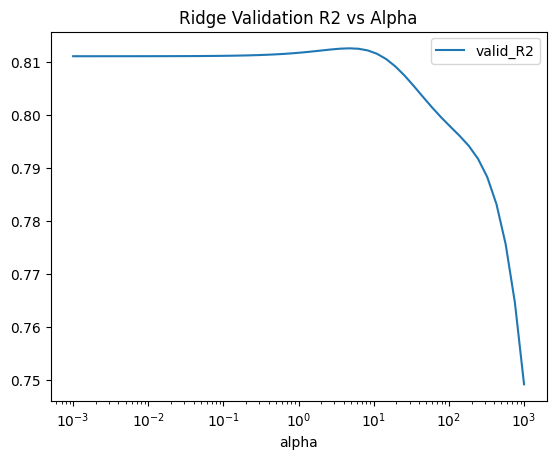

In [31]:
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np
import pandas as pd

# --- 1. Alpha grid (mokytojos stiliumi) ---
n_alphas = 50
alphas = 10 ** np.linspace(-3, 3, n_alphas)

# --- 2. RidgeCV modelis ---
ridge = RidgeCV(alphas=alphas, cv=5)
ridge.fit(X_tr_scaled, y_train)

# --- 3. Prognozės ---
y_pred_train = ridge.predict(X_tr_scaled)
y_pred_valid = ridge.predict(X_val_scaled)
y_pred_test  = ridge.predict(X_te_scaled)

print("Best alpha:", ridge.alpha_)
print("Train R2:", r2_score(y_train, y_pred_train))
print("Valid R2:", r2_score(y_valid, y_pred_valid))
print("Test R2:", r2_score(y_test, y_pred_test))
print("Test MAE:", mean_absolute_error(y_test, y_pred_test))

# --- 4. Koeficientai ---
coef = pd.Series(ridge.coef_, index=X_train.columns)
print("\nRidge coefficients:")
display(coef)

# --- 5. Vizualizacija (mokytojos stiliumi) ---
results = []

for a in alphas:
    model = Ridge(alpha=a)
    model.fit(X_tr_scaled, y_train)
    y_pred = model.predict(X_val_scaled)

    results.append({
        "alpha": a,
        "valid_R2": r2_score(y_valid, y_pred)
    })

ridge_scores_df = pd.DataFrame(results)

# Grafikas
ridge_scores_df.set_index("alpha").plot(logx=True, title="Ridge Validation R2 vs Alpha")


# Assignment 2: Lasso Regression

Fit a lasso regression model using LassoCV and compare the accuracy to the models above! 

Did any coefficient values drop to zero?

Best alpha: 0.001
Train R2: 0.7990178822046732
Valid R2: 0.8034488971902872
Test R2: 0.8000217198415679
Test MAE: 0.08496142570573119

Number of coefficients equal to 0: 2


const          0.000000
speed          0.085213
hd             0.180404
ram            0.112819
screen         0.045433
ads            0.014418
trend         -0.186978
hd2           -0.090132
hd3            0.000000
cd_yes         0.019338
multi_yes      0.016103
premium_yes   -0.069256
dtype: float64

<Axes: title={'center': 'Lasso Validation R2 vs Alpha'}, xlabel='alpha'>

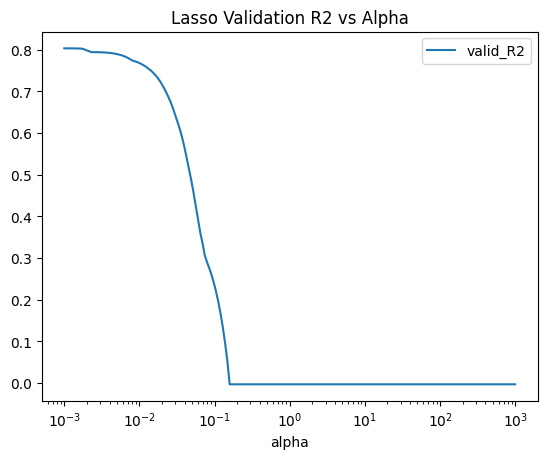

In [30]:
from sklearn.linear_model import Lasso, LassoCV
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np
import pandas as pd

# --- 1. Alpha grid (mokytojos stiliumi) ---
n_alphas = 200
alphas = 10 ** np.linspace(-3, 3, n_alphas)

# --- 2. LassoCV modelis ---
lasso = LassoCV(alphas=alphas, cv=5, max_iter=5000)
lasso.fit(X_tr_scaled, y_train)

# --- 3. Prognozės ---
y_pred_train = lasso.predict(X_tr_scaled)
y_pred_valid = lasso.predict(X_val_scaled)
y_pred_test  = lasso.predict(X_te_scaled)

print("Best alpha:", lasso.alpha_)
print("Train R2:", r2_score(y_train, y_pred_train))
print("Valid R2:", r2_score(y_valid, y_pred_valid))
print("Test R2:", r2_score(y_test, y_pred_test))
print("Test MAE:", mean_absolute_error(y_test, y_pred_test))

# --- 4. Koeficientai ---
coef = pd.Series(lasso.coef_, index=X_train.columns)
print("\nNumber of coefficients equal to 0:", sum(coef == 0))
display(coef)

# --- 5. Vizualizacija (mokytojos stiliumi) ---
results = []

for a in alphas:
    model = Lasso(alpha=a, max_iter=5000)
    model.fit(X_tr_scaled, y_train)
    y_pred = model.predict(X_val_scaled)

    results.append({
        "alpha": a,
        "valid_R2": r2_score(y_valid, y_pred)
    })

lasso_scores_df = pd.DataFrame(results)

# Grafikas
lasso_scores_df.set_index("alpha").plot(logx=True, title="Lasso Validation R2 vs Alpha")




## Assignment 3: Elastic Net Regression

Fit an elastic net regression model using ElasticNetCV and compare the accuracy to the models above! 

What was the optimal L1 Ratio?

Best alpha: 0.001
Best L1 ratio: 0.01
Train R2: 0.8043966703829292
Valid R2: 0.8125149066556732
Test R2: 0.8049091553665265
Test MAE: 0.08469455423034139

Number of coefficients equal to 0: 1


const          0.000000
speed          0.084994
hd             0.268969
ram            0.113405
screen         0.045281
ads            0.013017
trend         -0.189784
hd2           -0.263293
hd3            0.092857
cd_yes         0.020058
multi_yes      0.016841
premium_yes   -0.071748
dtype: float64

<Axes: title={'center': 'Elastic Net Validation R2 vs Alpha'}, xlabel='alpha'>

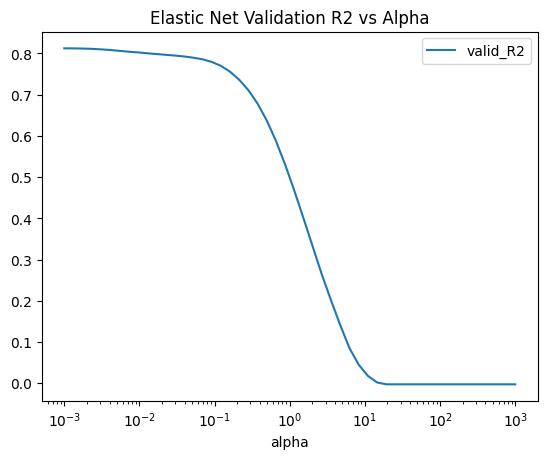

In [35]:
from sklearn.linear_model import ElasticNetCV, ElasticNet
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np
import pandas as pd

# --- 1. Alpha grid (mokytojos stiliumi) ---
n_alphas = 50
alphas = 10 ** np.linspace(-3, 3, n_alphas)

# --- 2. L1 ratio grid (nuo 0 = Ridge iki 1 = Lasso) ---
l1_ratios = np.linspace(0.01, 0.99, 20)

# --- 3. ElasticNetCV modelis ---
elastic = ElasticNetCV(
    alphas=alphas,
    l1_ratio=l1_ratios,
    cv=5,
    max_iter=5000
)
elastic.fit(X_tr_scaled, y_train)

# --- 4. Prognozės ---
y_pred_train = elastic.predict(X_tr_scaled)
y_pred_valid = elastic.predict(X_val_scaled)
y_pred_test  = elastic.predict(X_te_scaled)

print("Best alpha:", elastic.alpha_)
print("Best L1 ratio:", elastic.l1_ratio_)
print("Train R2:", r2_score(y_train, y_pred_train))
print("Valid R2:", r2_score(y_valid, y_pred_valid))
print("Test R2:", r2_score(y_test, y_pred_test))
print("Test MAE:", mean_absolute_error(y_test, y_pred_test))

# --- 5. Koeficientai ---
coef = pd.Series(elastic.coef_, index=X_train.columns)
print("\nNumber of coefficients equal to 0:", sum(coef == 0))
display(coef)

# --- 6. Vizualizacija: R2 vs alpha (be raudonos linijos) ---
results = []

for a in alphas:
    model = ElasticNet(alpha=a, l1_ratio=elastic.l1_ratio_, max_iter=5000)
    model.fit(X_tr_scaled, y_train)
    y_pred = model.predict(X_val_scaled)

    results.append({
        "alpha": a,
        "valid_R2": r2_score(y_valid, y_pred)
    })

elastic_scores_df = pd.DataFrame(results)

# Grafikas be vertikalios linijos
elastic_scores_df.set_index("alpha").plot(
    logx=True,
    title="Elastic Net Validation R2 vs Alpha"
)


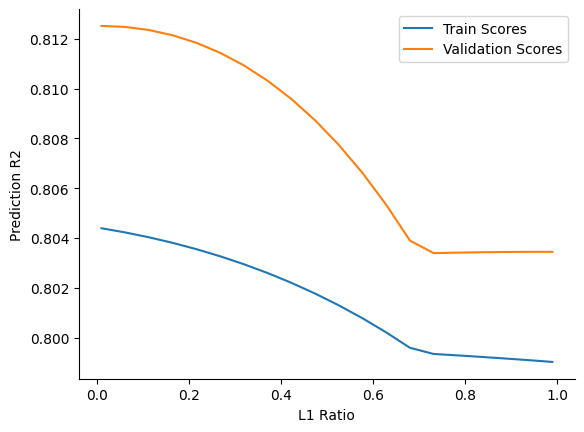

In [36]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import r2_score
import numpy as np
import matplotlib.pyplot as plt

# L1 ratio grid
l1_ratios = np.linspace(0.01, 0.99, 20)

train_scores = []
val_scores = []

for r in l1_ratios:
    model = ElasticNet(alpha=elastic.alpha_, l1_ratio=r, max_iter=5000)
    model.fit(X_tr_scaled, y_train)

    # Train R2
    y_pred_train = model.predict(X_tr_scaled)
    train_scores.append(r2_score(y_train, y_pred_train))

    # Validation R2
    y_pred_val = model.predict(X_val_scaled)
    val_scores.append(r2_score(y_valid, y_pred_val))

# --- Vizualizacija ---
fig, ax = plt.subplots()

ax.plot(l1_ratios, train_scores, label="Train Scores")
ax.plot(l1_ratios, val_scores, label="Validation Scores")

ax.set_xlabel("L1 Ratio")
ax.set_ylabel("Prediction R2")

ax.spines[["top", "right"]].set_visible(False)
ax.legend()
